Dataset Loaded Successfully
Dataset Shape: (50000, 30)
Detected Target Column: Is_Fraudulent
Feature Shape: (50000, 29)
Target Shape: (50000,)

Training Random Forest...

Top 10 Important Features
                               Feature  Importance
27     Provider_Patient_Distance_Miles      0.3026
26  Number_of_Previous_Claims_Provider      0.2504
18                Number_of_Procedures      0.1749
25   Number_of_Previous_Claims_Patient      0.1338
21                 Length_of_Stay_Days      0.0429
7                          Patient_Age      0.0301
6                         Claim_Amount      0.0219
19                      Admission_Type      0.0135
24                        CoPay_Amount      0.0107
28                Claim_Submitted_Late      0.0098

Table Saved Successfully
C:\Users\dheer\Desktop\ML\RQ4_table.csv


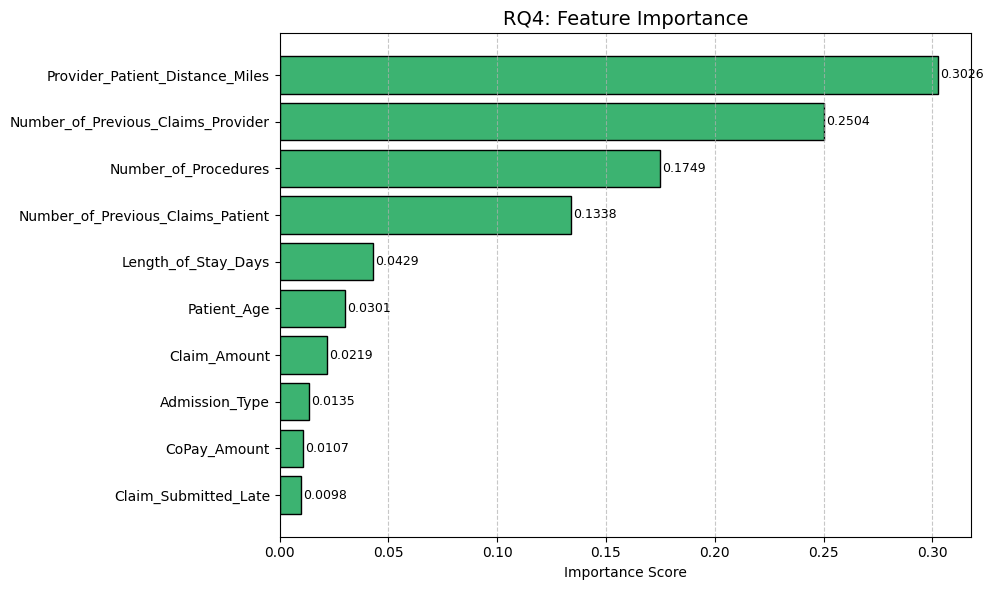


Figure Saved Successfully
C:\Users\dheer\Desktop\ML\RQ4_figure.pdf

RQ4 Completed Successfully


In [1]:
# ============================================
# RQ4: Feature Importance
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------

df = pd.read_csv(
    r"C:\Users\dheer\Desktop\ML\cleaned_dataset.csv"
)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# --------------------------------------------
# Step 2: Detect Target Column
# --------------------------------------------

target_col = None

for col in df.columns:
    if 'fraud' in col.lower():
        target_col = col
        break

print("Detected Target Column:", target_col)

if target_col is None:
    raise Exception("Fraud column not found")

# --------------------------------------------
# Step 3: Define Features and Target
# --------------------------------------------

y = df[target_col]
X = df.drop(columns=[target_col])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# --------------------------------------------
# Step 4: Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------
# Step 5: Train Random Forest Model
# --------------------------------------------

model = RandomForestClassifier()

print("\nTraining Random Forest...")

model.fit(
    X_train,
    y_train
)

# --------------------------------------------
# Step 6: Extract Feature Importance
# --------------------------------------------

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = importance_df.head(10)

top_features = top_features.round(4)

print("\nTop 10 Important Features")
print(top_features)

# --------------------------------------------
# Step 7: Save Results Table
# --------------------------------------------

table_path = r"C:\Users\dheer\Desktop\ML\RQ4_table.csv"

top_features.to_csv(
    table_path,
    index=False
)

print("\nTable Saved Successfully")
print(table_path)

# --------------------------------------------
# Step 8: Create Figure
# --------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features['Feature'],
    top_features['Importance'],
    color='mediumseagreen',
    edgecolor='black'
)

# Add value labels
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}',
        va='center',
        fontsize=9
    )

plt.title(
    'RQ4: Feature Importance',
    fontsize=14
)

plt.xlabel('Importance Score')

plt.gca().invert_yaxis()

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# --------------------------------------------
# Step 9: Save Figure
# --------------------------------------------

figure_path = r"C:\Users\dheer\Desktop\ML\RQ4_figure.pdf"

plt.savefig(
    figure_path,
    bbox_inches='tight'
)

plt.show()

print("\nFigure Saved Successfully")
print(figure_path)

# --------------------------------------------
# Completed
# --------------------------------------------

print("\nRQ4 Completed Successfully")